In [ ]:
# Notebook 3
# Elaboren un notebook que con el O3 hoario de UIZ:
# a) Cuente los faltantes y decida cómo tratarlos
# b) Grafique la serie y su ACF hasta 72 h
# c) Corrra ADF y KPSS
# d) Reste la media de cada hora del día y repita c)
# e) Reste la media de cada mes * hora y repita c)
# f) Haga la diferencia de 24 h, repita c) y compare su ACF y su varianza con las de e

In [3]:
# a) Cuente los faltantes y decida cómo tratarlos
import pandas as pd, numpy as np

df = pd.read_csv("contaminantes_2026.csv", skiprows=9)
df["date"] = pd.to_datetime(df["date"], format="mixed")

# O3 de UIZ
o3 = df[(df["id_station"] == "UIZ") & (df["id_parameter"] == "O3")].copy()

col = "valor" if o3["valor"].notna().any() else "unit"
o3["y"] = pd.to_numeric(o3[col], errors="coerce")
o3.loc[o3["y"] < 0, "y"] = np.nan

s = o3.drop_duplicates("date").set_index("date")["y"].sort_index()
s = s.loc[:s.last_valid_index()]
s = s.asfreq("h")

# Conteo de faltantes
n, faltan = len(s), s.isna().sum()
print(f"Horas totales: {n} | Faltantes: {faltan} ({faltan/n:.2%})")

# Hueco consecutivo más largo
grupos = s.isna().ne(s.isna().shift()).cumsum()
huecos = s.isna().groupby(grupos).sum()
print("Hueco más largo (h):", int(huecos.max()))

s_orig = s.copy()
s = s.interpolate(method="time", limit_direction="both")
print("Faltantes tras interpolar:", s.isna().sum())

Horas totales: 5088 | Faltantes: 228 (4.48%)
Hueco más largo (h): 49
Faltantes tras interpolar: 0


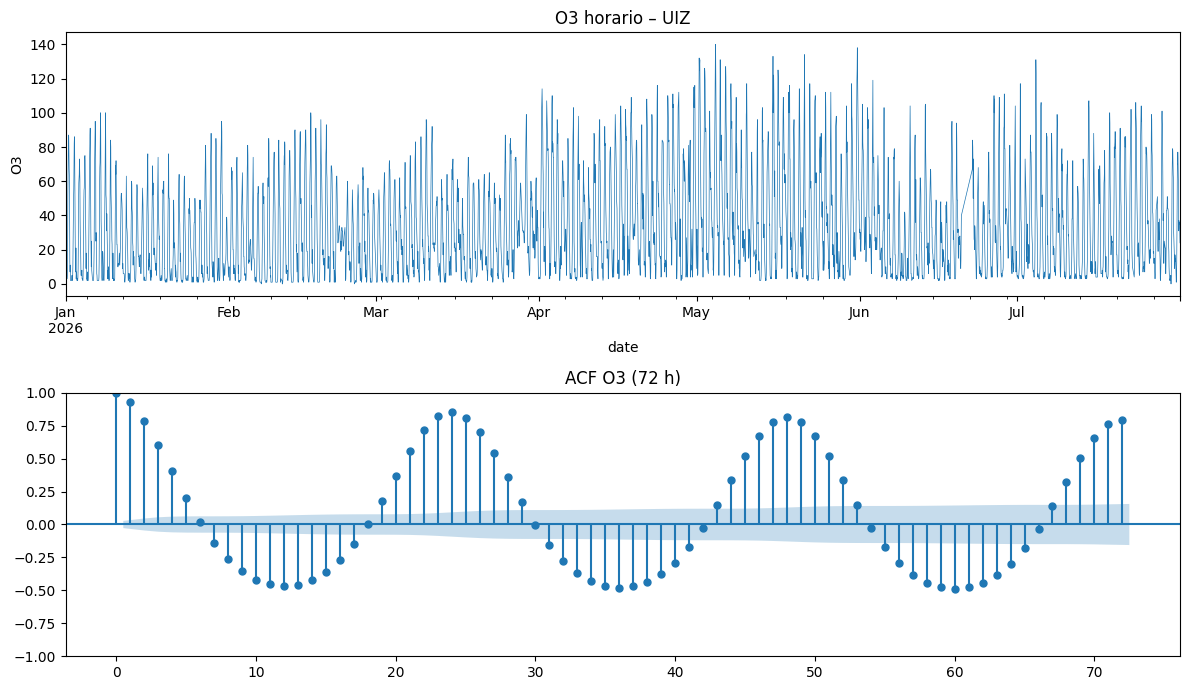

In [4]:
# b) Grafique la serie y su ACF hasta 72 h
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(2, 1, figsize=(12, 7))
s.plot(ax=ax[0], lw=0.5, title="O3 horario – UIZ")
ax[0].set_ylabel("O3")
plot_acf(s, lags=72, ax=ax[1], title="ACF O3 (72 h)")
plt.tight_layout()
plt.show()

In [5]:
# c) Corrra ADF y KPSS
import warnings
from statsmodels.tsa.stattools import adfuller, kpss

def pruebas(x, nombre):
    x = x.dropna()
    adf_stat, adf_p, *_ = adfuller(x, autolag="AIC")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
    res = pd.DataFrame({
        "estadístico": [adf_stat, kpss_stat],
        "p-value": [adf_p, kpss_p],
        "H0": ["raíz unitaria (no estacionaria)", "estacionaria"],
        "conclusión (5%)": [
            "estacionaria" if adf_p < 0.05 else "no estacionaria",
            "no estacionaria" if kpss_p < 0.05 else "estacionaria",
        ],
    }, index=["ADF", "KPSS"])
    print(f"\n=== {nombre} ===")
    print(res.round(4))
    return res

r_orig = pruebas(s, "Serie original")


=== Serie original ===
      estadístico  p-value                               H0  conclusión (5%)
ADF       -5.9288     0.00  raíz unitaria (no estacionaria)     estacionaria
KPSS       2.5908     0.01                     estacionaria  no estacionaria


/tmp/ipykernel_574/499388270.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, *_ = adfuller(x, autolag="AIC")


In [6]:
# d) Reste la media de cada hora del día y repita c)
s_h = s - s.groupby(s.index.hour).transform("mean")
r_h = pruebas(s_h, "Sin media por hora del día")


=== Sin media por hora del día ===
      estadístico  p-value                               H0  conclusión (5%)
ADF       -5.9273     0.00  raíz unitaria (no estacionaria)     estacionaria
KPSS       2.7399     0.01                     estacionaria  no estacionaria


/tmp/ipykernel_574/499388270.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, *_ = adfuller(x, autolag="AIC")


In [7]:
# e) Reste la media de cada mes * hora y repita c)
s_mh = s - s.groupby([s.index.month, s.index.hour]).transform("mean")
r_mh = pruebas(s_mh, "Sin media por mes × hora")


=== Sin media por mes × hora ===
      estadístico  p-value                               H0 conclusión (5%)
ADF       -7.6897      0.0  raíz unitaria (no estacionaria)    estacionaria
KPSS       0.0487      0.1                     estacionaria    estacionaria


/tmp/ipykernel_574/499388270.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, *_ = adfuller(x, autolag="AIC")


/tmp/ipykernel_574/499388270.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, *_ = adfuller(x, autolag="AIC")



=== Diferencia de 24 h ===
      estadístico  p-value                               H0 conclusión (5%)
ADF      -15.5977      0.0  raíz unitaria (no estacionaria)    estacionaria
KPSS       0.0090      0.1                     estacionaria    estacionaria

Varianza (e) mes×hora: 165.232
Varianza diff 24 h  : 241.979
Cociente diff24/e   : 1.464


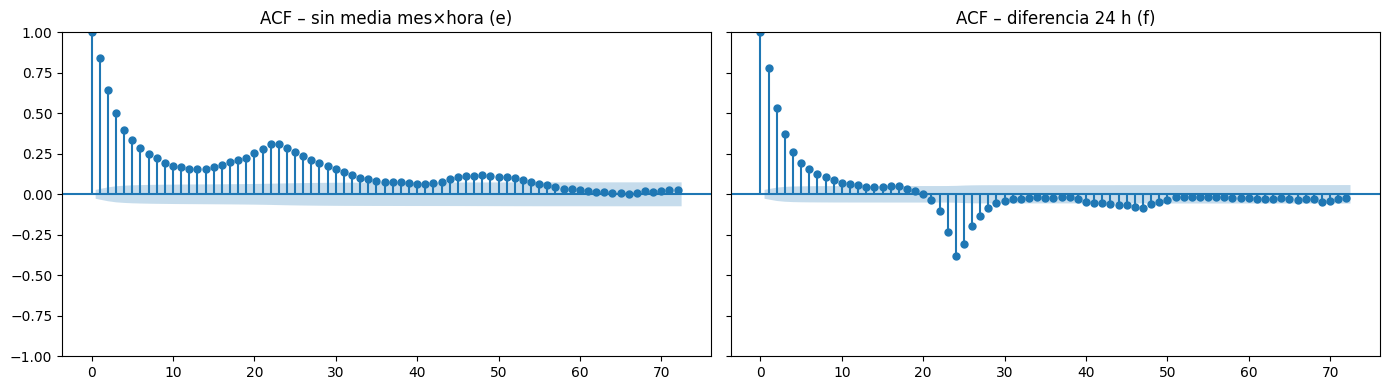

        e) mes×hora  f) diff 24h
lag 24        0.285       -0.379
lag 48        0.117       -0.061
lag 72        0.024       -0.024


In [8]:
# f) Haga la diferencia de 24 h, repita c) y compare su ACF y su varianza con las de e)
from statsmodels.tsa.stattools import acf

s_d24 = s.diff(24).dropna()
r_d24 = pruebas(s_d24, "Diferencia de 24 h")

# Varianzas
print("\nVarianza (e) mes×hora:", round(s_mh.var(), 3))
print("Varianza diff 24 h  :", round(s_d24.var(), 3))
print("Cociente diff24/e   :", round(s_d24.var() / s_mh.var(), 3))

# ACF comparada
lags = 72
fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
plot_acf(s_mh, lags=lags, ax=ax[0], title="ACF – sin media mes×hora (e)")
plot_acf(s_d24, lags=lags, ax=ax[1], title="ACF – diferencia 24 h (f)")
plt.tight_layout()
plt.show()

# Correlaciones en los rezagos de 24, 48 y 72 h
a_e, a_f = acf(s_mh, nlags=lags), acf(s_d24, nlags=lags)
print(pd.DataFrame({"e) mes×hora": a_e[[24, 48, 72]],
                    "f) diff 24h": a_f[[24, 48, 72]]},
                   index=["lag 24", "lag 48", "lag 72"]).round(3))